# trick time stamp

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import gc
import io
import os
from itertools import combinations

from IPython.display import display

pd.set_option('display.max_columns', 99)
pd.set_option('display.max_rows', 200)

pd.reset_option('display.float_format')
pd.set_option('display.max_colwidth', None)

from config import ROOT  # lib này được khởi tạo ban đầu dự án

import helpers.view as view
import helpers.EDA as EDA
import modules.utils as utils

importlib.reload(view)
importlib.reload(EDA)
importlib.reload(utils)

from helpers.cache_clear import cache_clear

In [2]:
get_pickle = utils.get_pickle
get_pickles = utils.get_pickles

In [3]:
_keep_vars = set(globals().keys())  # lưu biến gốc

* vì bộ dữ liệu bị drop mất CNT_PAYMENT, timestamp trong train, test nên thử filling

# prev application

In [4]:
prev = get_pickles("prev", ['SK_ID_CURR', "SK_ID_PREV", 'NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', "DAYS_DECISION", "interest_rate", "CNT_PAYMENT", "NAME_TYPE_SUITE", "WEEKDAY_APPR_PROCESS_START",	"HOUR_APPR_PROCESS_START"])

In [5]:
train = get_pickle("train")
test = get_pickle("test")

In [6]:
train_id = get_pickle("train")["SK_ID_CURR"]
test_id = get_pickle("test")["SK_ID_CURR"]

In [7]:
prev.loc[prev["SK_ID_CURR"].isin(train_id), "data"] = 1
prev.loc[prev["SK_ID_CURR"].isin(test_id), "data"] = 0

In [8]:
prev.head(10)

,SK_ID_CURR,SK_ID_PREV,NAME_CONTRACT_TYPE,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_DECISION,interest_rate,CNT_PAYMENT,NAME_TYPE_SUITE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,data
0,100001,1369693,Consumer loans,23787.0,3951.000,24835.50,-1740,0.067887,8.0,Family,FRIDAY,13,0.0
1,100002,1038818,Consumer loans,179055.0,9251.775,179055.00,-606,0.017982,24.0,None,SATURDAY,9,1.0
2,100003,2396755,Consumer loans,68053.5,6737.310,68809.50,-2341,0.027553,12.0,Family,SATURDAY,15,1.0
3,100003,2636178,Consumer loans,348637.5,64567.665,337500.00,-828,0.030984,6.0,Family,SUNDAY,17,1.0
4,100003,1810518,Cash loans,1035882.0,98356.995,900000.00,-746,0.020672,12.0,Unaccompanied,FRIDAY,12,1.0
5,100004,1564014,Consumer loans,20106.0,5357.250,24282.00,-815,0.025987,4.0,Unaccompanied,FRIDAY,5,1.0
6,100005,2495675,Consumer loans,40153.5,4813.200,44617.50,-757,0.060906,12.0,None,THURSDAY,11,0.0
7,100005,1857999,Cash loans,NaN,NaN,NaN,-315,NaN,NaN,None,FRIDAY,10,0.0
8,100006,2299329,Consumer loans,24219.0,2482.920,26912.34,-617,0.033413,12.0,None,TUESDAY,15,1.0
9,100006,1020698,Cash loans,481495.5,39954.510,454500.00,-438,0.046131,18.0,None,SATURDAY,12,1.0


# prev của test chứa các khoản vay ở thời điểm tương lai hơn so với prev của test (lệch pha khoảng 150 đến 200 ngày)

* dữ liệu rất mù mờ về thời điểm, chỉ chứa khoảng thời gian từ ngày prev được quyết định đến ngày app được ký 

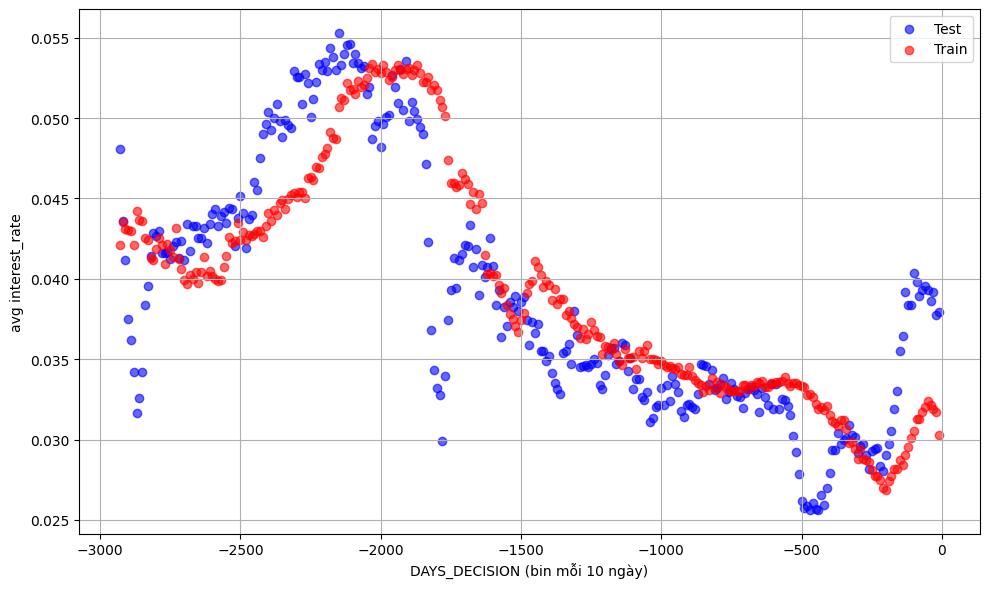

In [9]:
prev["DAYS_DECISION_BIN"] = (prev["DAYS_DECISION"] // 10) * 10
avg_interest = prev.groupby(["data", "DAYS_DECISION_BIN"])["interest_rate"].mean().reset_index()
plt.figure(figsize=(10, 6))

colors = {0: 'blue', 1: 'red'}
labels = {0: 'Test', 1: 'Train'}

for d in avg_interest["data"].unique():
    subset = avg_interest[avg_interest["data"] == d]
    plt.scatter(subset["DAYS_DECISION_BIN"], subset["interest_rate"],
                color=colors[d], label=labels[d], alpha=0.6)

plt.xlabel("DAYS_DECISION (bin mỗi 10 ngày)")
plt.ylabel("avg interest_rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# tham khảo https://www.kaggle.com/c/home-credit-default-risk/discussion/64784

# giả thiết

* vì đơn vị trục x là DAYS_DECISION, khoảng thời gian từ ngày của đơn trước đến ngày của đơn hiện tại, nên ta có giả thiết

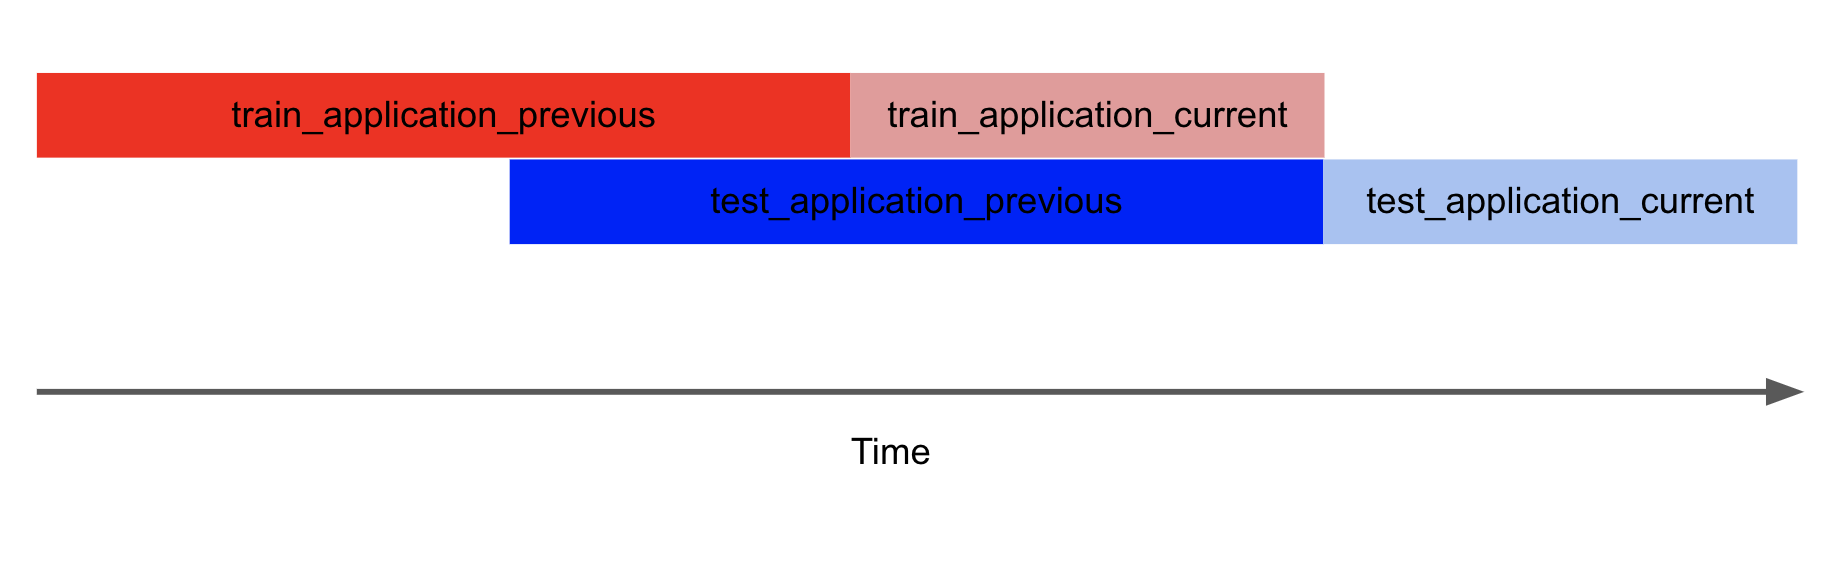

In [14]:
bureau = get_pickle("bureau")[["SK_ID_BUREAU", "SK_ID_CURR"]]

In [10]:
bureau = bureau.groupby("SK_ID_CURR")[["SK_ID_BUREAU"]].max().reset_index()

In [11]:
prev = pd.merge(prev, bureau, on="SK_ID_CURR",how="left")

In [12]:
train["data"]=1
test["data"]=0

In [13]:
train = pd.merge(train, bureau, on="SK_ID_CURR", how="left")
test = pd.merge(test, bureau, on="SK_ID_CURR", how="left")

In [14]:
trte = pd.concat([train, test])

In [25]:
prev

,SK_ID_CURR,SK_ID_PREV,NAME_CONTRACT_TYPE,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_DECISION,interest_rate,CNT_PAYMENT,NAME_TYPE_SUITE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,data,SK_ID_BUREAU
0,100001,1369693,Consumer loans,23787.0,3951.000,24835.5,-1740,0.067887,8.0,Family,FRIDAY,13,0.0,5896636.0
1,100002,1038818,Consumer loans,179055.0,9251.775,179055.0,-606,0.017982,24.0,None,SATURDAY,9,1.0,6158909.0
2,100003,2396755,Consumer loans,68053.5,6737.310,68809.5,-2341,0.027553,12.0,Family,SATURDAY,15,1.0,5885880.0
3,100003,2636178,Consumer loans,348637.5,64567.665,337500.0,-828,0.030984,6.0,Family,SUNDAY,17,1.0,5885880.0
4,100003,1810518,Cash loans,1035882.0,98356.995,900000.0,-746,0.020672,12.0,Unaccompanied,FRIDAY,12,1.0,5885880.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670209,313625,1180032,Consumer loans,74011.5,16746.075,78975.0,-2024,0.042589,5.0,Other_A,WEDNESDAY,14,0.0,NaN
1670210,313625,1956899,Revolving loans,135000.0,6750.000,NaN,-1548,NaN,NaN,None,WEDNESDAY,14,0.0,NaN
1670211,313625,2806705,Cash loans,NaN,NaN,NaN,-276,NaN,NaN,None,MONDAY,10,0.0,NaN
1670212,313625,2803926,Cash loans,315000.0,14815.800,315000.0,-276,0.039814,48.0,Unaccompanied,MONDAY,10,0.0,NaN


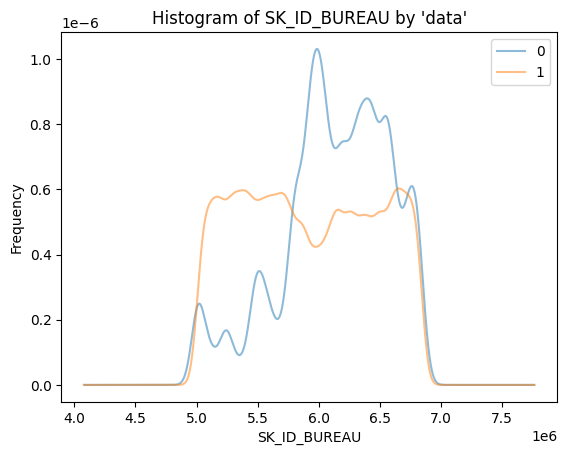

In [15]:
for key, group in trte[["data", "SK_ID_BUREAU"]].groupby("data"):
    group["SK_ID_BUREAU"].plot(kind="kde", legend=True, label=str(key), alpha=0.5)
    
plt.legend()
plt.title("Histogram of SK_ID_BUREAU by 'data'")
plt.xlabel("SK_ID_BUREAU")
plt.ylabel("Frequency")
plt.show()

* SK_ID_BUREAU max gần với thời điểm của SK_ID_CURR, tức là DAY_CREDIT nhỏ
* test có xu hướng chứa SK_ID_BUREAU lớn hơn => test nằm ở khoảng thời gian sau so với train

=> SK_ID_BUREAU max có tương quan thời gian (tương đối)

In [16]:
_keep_vars.update(["prev"])

In [17]:
cache_clear(globals(), _keep_vars)

# tính interest_rate cho khoản vay hiện tại

* vấn đề 1: application không có CNT_PAYMENT để tính interest rate (thử các giá trị phổ biến của CNT_PAYMENT, sử dụng mô hình dự đoán)
* vấn đề 2: interest rate thay đổi theo thời gian (sử dụng SK_ID_BUREAU như ở trên)

In [65]:
train = get_pickle("train")
test = get_pickle("test")

In [66]:
trte = pd.concat([train, test])

In [67]:
prev = get_pickles("prev", ['SK_ID_CURR', "SK_ID_PREV", 'NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', "DAYS_DECISION", "interest_rate", "CNT_PAYMENT", "NAME_TYPE_SUITE", "WEEKDAY_APPR_PROCESS_START",	"HOUR_APPR_PROCESS_START"])

## 1. knowledge

* CNT_PAYMENT không phải giá trị rời rạc, tức là nó sẽ kiểu [6, 12, 18, 24...] tháng. có thể bổ sung các tháng phổ biến khác như 5, 10, 15...

In [68]:
def compute_interest_rate(amt_annuity, amt_credit, cnt_payment, init_rate=0.9, n_iter=500): # hội tụ
    temp = amt_annuity / amt_credit
    r = init_rate
    for _ in range(n_iter):
        r = temp * ((1 + r)**cnt_payment - 1) / ((1 + r)**cnt_payment)
    return r

In [69]:
possible_cnts = [6, 12, 18, 24, 30, 36, 42, 48, 54, 60]

def calc_possible_rates(row):
    rates = []
    for cnt in possible_cnts:
        try:
            r = compute_interest_rate(row['AMT_ANNUITY'], row['AMT_CREDIT'], cnt)
            rates.append(r)
        except:
            rates.append(np.nan)
    return pd.Series({
        'interest_rate_min': np.nanmin(rates),
        'interest_rate_max': np.nanmax(rates),
        'interest_rate_median': np.nanmedian(rates),
        'interest_rate_std': np.nanstd(rates)
    })

In [70]:
interest_rate_features = trte[["AMT_ANNUITY", "AMT_CREDIT"]].apply(calc_possible_rates, axis=1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_10048\4151008401.py:12: RuntimeWarning: All-NaN axis encountered
  'interest_rate_min': np.nanmin(rates),
C:\Users\Admin\AppData\Local\Temp\ipykernel_10048\4151008401.py:13: RuntimeWarning: All-NaN axis encountered
  'interest_rate_max': np.nanmax(rates),
C:\Users\Admin\AppData\Local\Temp\ipykernel_10048\4151008401.py:14: RuntimeWarning: All-NaN slice encountered
  'interest_rate_median': np.nanmedian(rates),
d:\Data Science\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [71]:
interest_rate_features

,interest_rate_min,interest_rate_max,interest_rate_median,interest_rate_std
0,0.000000e+00,0.058775,0.047257,0.023047
1,0.000000e+00,0.018303,0.000007,0.007036
2,0.000000e+00,0.046782,0.032227,0.018927
3,1.264873e-16,0.094521,0.088999,0.032297
4,0.000000e+00,0.038102,0.020958,0.015653
...,...,...,...,...
48739,0.000000e+00,0.037776,0.020528,0.015548
48740,0.000000e+00,0.048230,0.034074,0.019539
48741,1.404400e-16,0.105153,0.100747,0.033942
48742,0.000000e+00,0.053374,0.040562,0.021726


In [74]:
trte = pd.concat([trte, interest_rate_features], axis=1)

In [75]:
trte

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,...,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,interest_rate_min,interest_rate_max,interest_rate_median,interest_rate_std
0,100002,1.0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,...,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000e+00,0.058775,0.047257,0.023047
1,100003,0.0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,...,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.018303,0.000007,0.007036
2,100004,0.0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,None,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.046782,0.032227,0.018927
3,100006,0.0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,None,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1.264873e-16,0.094521,0.088999,0.032297
4,100007,0.0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / seconda

In [76]:
train = trte[~trte["TARGET"].isnull()]

In [78]:
train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,...,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,interest_rate_min,interest_rate_max,interest_rate_median,interest_rate_std
0,100002,1.0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,...,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000e+00,0.058775,0.047257,0.023047
1,100003,0.0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,...,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.018303,0.000007,0.007036
2,100004,0.0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,None,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.046782,0.032227,0.018927
3,100006,0.0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,None,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1.264873e-16,0.094521,0.088999,0.032297
4,100007,0.0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / seconda

In [77]:
test = trte[trte["TARGET"].isnull()]

In [79]:
test

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,...,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,interest_rate_min,interest_rate_max,interest_rate_median,interest_rate_std
0,100001,NaN,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,None,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,...,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0514,NaN,NaN,None,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.030018,0.010151,0.012109
1,100005,NaN,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,None,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,0.000000e+00,0.077067,0.069116,0.029098
2,100013,NaN,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,None,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,None,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0,1.401578e-16,0.104938,0.100512,0.033904
3,100028,NaN,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.026392,-13976,-1866,-2000.0,-4208,NaN,1,1,0,1,1,0,Sales staff,4.0,2,2,WEDNESDAY,11,0,0,0,0,0,0,Business Entity Type 3,0.525734,0.509677,0.612704,0.3052,0.1974,0.9970,0.9592,0.1165,...,0.32,0.2759,0.3750,0.0417,0.2078,0.2446,0.3739,0.0388,0.0817,reg oper account,block of flats,0.3700,Panel,No,0.0,0.0,0.0,0.0,-1805.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,0.000000e+00,0.023315,0.003140,0.009203
4,100038,NaN,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.010032,-13040,-2191,-4000.0,-4

In [80]:
train[["SK_ID_CURR", "interest_rate_min", "interest_rate_max", "interest_rate_median", "interest_rate_std"]].to_pickle(ROOT + "/data/feature/train/interest_rate_train.p")

In [81]:
test[["SK_ID_CURR", "interest_rate_min", "interest_rate_max", "interest_rate_median", "interest_rate_std"]].to_pickle(ROOT + "/data/feature/test/interest_rate_test.p")

In [ ]:
_keep_vars.update(["prev"])

In [104]:
cache_clear(globals(), _keep_vars)

## 2. dùng stacking lightgbm + kfold để predict CNT_PAYMENT cho application train test

In [4]:
import lightgbm as lgb
import multiprocessing
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [5]:
SEED = 71
param = {
    'objective': 'regression',       
    'metric': 'rmse',                
    'learning_rate': 0.05,
    'max_depth': -1,
    'num_leaves': 255,
    'max_bin': 255,
    'colsample_bytree': 0.5,
    'subsample': 0.5,
    'nthread': multiprocessing.cpu_count(),
    'bagging_freq': 1,
    'seed': SEED
}

In [111]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

In [35]:
prev=prev.dropna(subset=['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'CNT_PAYMENT'])

In [36]:
prev

,SK_ID_CURR,SK_ID_PREV,NAME_CONTRACT_TYPE,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_DECISION,interest_rate,CNT_PAYMENT,NAME_TYPE_SUITE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,data,SK_ID_BUREAU
0,100001,1369693,Consumer loans,23787.0,3951.000,24835.5,-1740,0.067887,8.0,Family,FRIDAY,13,0.0,5896636.0
1,100002,1038818,Consumer loans,179055.0,9251.775,179055.0,-606,0.017982,24.0,None,SATURDAY,9,1.0,6158909.0
2,100003,2396755,Consumer loans,68053.5,6737.310,68809.5,-2341,0.027553,12.0,Family,SATURDAY,15,1.0,5885880.0
3,100003,2636178,Consumer loans,348637.5,64567.665,337500.0,-828,0.030984,6.0,Family,SUNDAY,17,1.0,5885880.0
4,100003,1810518,Cash loans,1035882.0,98356.995,900000.0,-746,0.020672,12.0,Unaccompanied,FRIDAY,12,1.0,5885880.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670206,313623,1315634,Consumer loans,82764.0,16652.115,103455.0,-1800,0.056607,6.0,None,MONDAY,10,1.0,6251274.0
1670207,313623,2007015,Consumer loans,67455.0,6870.600,67455.0,-12,0.032314,12.0,Unaccompanied,THURSDAY,15,1.0,6251274.0
1670209,313625,1180032,Consumer loans,74011.5,16746.075,78975.0,-2024,0.042589,5.0,Other_A,WEDNESDAY,14,0.0,NaN
1670212,313625,2803926,Cash loans,315000.0,14815.800,315000.0,-276,0.039814,48.0,Unaccompanied,MONDAY,10,0.0,NaN


In [37]:
prev["NAME_TYPE_SUITE"] = prev["NAME_TYPE_SUITE"].fillna("None")

C:\Users\Admin\AppData\Local\Temp\ipykernel_18736\2721138022.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prev["NAME_TYPE_SUITE"] = prev["NAME_TYPE_SUITE"].fillna("None")


In [38]:
prev[prev.isna().any(axis=1)]

,SK_ID_CURR,SK_ID_PREV,NAME_CONTRACT_TYPE,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_DECISION,interest_rate,CNT_PAYMENT,NAME_TYPE_SUITE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,data,SK_ID_BUREAU
8,100006,2299329,Consumer loans,24219.0,2482.920,26912.34,-617,0.033413,12.0,None,TUESDAY,15,1.0,NaN
9,100006,1020698,Cash loans,481495.5,39954.510,454500.00,-438,0.046131,18.0,None,SATURDAY,12,1.0,NaN
10,100006,2190416,Consumer loans,267930.0,29027.520,334917.00,-311,0.042879,12.0,Family,SUNDAY,15,1.0,NaN
11,100006,2078043,Cash loans,675000.0,24246.000,675000.00,-181,0.024877,48.0,Unaccompanied,THURSDAY,15,1.0,NaN
16,100006,1697039,Cash loans,906615.0,32696.100,688500.00,-181,0.025083,48.0,Unaccompanied,THURSDAY,15,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670033,313590,2715625,Consumer loans,252198.0,18470.340,223443.00,-827,0.030859,18.0,Family,THURSDAY,12,1.0,NaN
1670052,313594,1820182,Consumer loans,87498.0,8167.050,79141.50,-291,0.017892,12.0,Family,FRIDAY,10,1.0,NaN
1670209,313625,1180032,Consumer loans,74011.5,16746.075,78975.00,-2024,0.042589,5.0,Other_A,WEDNESDAY,14,0.0,NaN
1670212,313625,2803926,Cash loans,315000.0,14815.800,315000.00,-276,0.039814,48.0,Unaccompanied,MONDAY,10,0.0,NaN


In [20]:
predict_interest_rate_cols = ['NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', "NAME_TYPE_SUITE", "WEEKDAY_APPR_PROCESS_START", "HOUR_APPR_PROCESS_START", "SK_ID_BUREAU"]

In [39]:
X = prev[predict_interest_rate_cols]
y = prev["interest_rate"]

In [40]:
X

,NAME_CONTRACT_TYPE,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,SK_ID_BUREAU
0,Consumer loans,23787.0,3951.000,24835.5,Family,FRIDAY,13,5896636.0
1,Consumer loans,179055.0,9251.775,179055.0,None,SATURDAY,9,6158909.0
2,Consumer loans,68053.5,6737.310,68809.5,Family,SATURDAY,15,5885880.0
3,Consumer loans,348637.5,64567.665,337500.0,Family,SUNDAY,17,5885880.0
4,Cash loans,1035882.0,98356.995,900000.0,Unaccompanied,FRIDAY,12,5885880.0
...,...,...,...,...,...,...,...,...
1670206,Consumer loans,82764.0,16652.115,103455.0,None,MONDAY,10,6251274.0
1670207,Consumer loans,67455.0,6870.600,67455.0,Unaccompanied,THURSDAY,15,6251274.0
1670209,Consumer loans,74011.5,16746.075,78975.0,Other_A,WEDNESDAY,14,NaN
1670212,Cash loans,315000.0,14815.800,315000.0,Unaccompanied,MONDAY,10,NaN


In [41]:
y

0          0.067887
1          0.017982
2          0.027553
3          0.030984
4          0.020672
             ...   
1670206    0.056607
1670207    0.032314
1670209    0.042589
1670212    0.039814
1670213    0.034584
Name: interest_rate, Length: 1152941, dtype: float64

In [42]:
for col in prev.select_dtypes(include=['object']).columns:
    prev[col] = prev[col].astype('category')

C:\Users\Admin\AppData\Local\Temp\ipykernel_18736\368901404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prev[col] = prev[col].astype('category')
C:\Users\Admin\AppData\Local\Temp\ipykernel_18736\368901404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prev[col] = prev[col].astype('category')
C:\Users\Admin\AppData\Local\Temp\ipykernel_18736\368901404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

In [ ]:
# one hot encode
# X = pd.get_dummies(X, columns=["NAME_CONTRACT_TYPE"], drop_first=True).astype(int)


# label encode
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
X['NAME_CONTRACT_TYPE'] = label_encoder.fit_transform(X['NAME_CONTRACT_TYPE'])
X['NAME_TYPE_SUITE'] = label_encoder.fit_transform(X['NAME_TYPE_SUITE'])
X['WEEKDAY_APPR_PROCESS_START'] = label_encoder.fit_transform(X['WEEKDAY_APPR_PROCESS_START'])

In [44]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
dtrain = lgb.Dataset(X_train, y_train)
dval = lgb.Dataset(X_val, y_val)
model = lgb.train(param, dtrain, valid_sets=[dval],
                    num_boost_round=5000,
                    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

preds = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, preds))
print(f"Single LightGBM model RMSE: {rmse:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1061
[LightGBM] [Info] Number of data points in the train set: 922352, number of used features: 8
[LightGBM] [Info] Start training from score 0.036126
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.0103419
[200]	valid_0's rmse: 0.00931708
[300]	valid_0's rmse: 0.00892619
[400]	valid_0's rmse: 0.00876284
[500]	valid_0's rmse: 0.00861457
[600]	valid_0's rmse: 0.00852555
[700]	valid_0's rmse: 0.00846151
[800]	valid_0's rmse: 0.00841839
[900]	valid_0's rmse: 0.0083676
[1000]	valid_0's rmse: 0.0083101
[1100]	valid_0's rmse: 0.00825646
[1200]	valid_0's rmse: 0.00819919
[1300]	valid_0's rmse: 0.00815226
[1400]	valid_0's rmse: 0.00812492
[1500]	valid_0's rmse: 0.00809844
[1600]	valid_0's rmse: 0.00806122
[

In [126]:
# import joblib
# joblib.dump(model, ROOT + '/models/rmse_0.0071_interest_rate_model.pkl')

['d:\\Data Science/models/rmse_0.0071_interest_rate_model.pkl']

In [151]:
# import joblib
# joblib.dump(model, ROOT + '/models/rmse_0.0076_interest_rate_model.pkl')

In [7]:
model = joblib.load(ROOT + '/models/rmse_0.0076_interest_rate_model.pkl')

In [99]:
train = get_pickle("train")
test = get_pickle("test")

In [98]:
interest_rate_train = pd.read_pickle(ROOT + "/data/feature/train/interest_rate_train.p")
interest_rate_test = pd.read_pickle(ROOT + "/data/feature/test/interest_rate_test.p")

In [100]:
train = pd.merge(train, interest_rate_train, on="SK_ID_CURR", how="left")

In [101]:
test = pd.merge(test, interest_rate_test, on="SK_ID_CURR", how="left")

In [104]:
train['data'] = 1
test['data'] = 0

In [105]:
bureau = bureau.groupby("SK_ID_CURR")[["SK_ID_BUREAU"]].max().reset_index()

In [106]:
train = pd.merge(train, bureau, on="SK_ID_CURR", how="left")

In [107]:
test = pd.merge(test, bureau, on="SK_ID_CURR", how="left")

In [109]:
trte = pd.concat([train, test])

In [113]:
data = trte[["data", "SK_ID_CURR"]]
trte = trte[predict_interest_rate_cols]

In [114]:
for col in trte.select_dtypes(include=['object']).columns:
    trte[col] = trte[col].astype('category')

C:\Users\Admin\AppData\Local\Temp\ipykernel_10048\1157253948.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trte[col] = trte[col].astype('category')
C:\Users\Admin\AppData\Local\Temp\ipykernel_10048\1157253948.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trte[col] = trte[col].astype('category')
C:\Users\Admin\AppData\Local\Temp\ipykernel_10048\1157253948.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

In [115]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

trte['NAME_CONTRACT_TYPE'] = label_encoder.fit_transform(trte['NAME_CONTRACT_TYPE'])
trte['NAME_TYPE_SUITE'] = label_encoder.fit_transform(trte['NAME_TYPE_SUITE'])
trte['WEEKDAY_APPR_PROCESS_START'] = label_encoder.fit_transform(trte['WEEKDAY_APPR_PROCESS_START'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_10048\3985438928.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trte['NAME_CONTRACT_TYPE'] = label_encoder.fit_transform(trte['NAME_CONTRACT_TYPE'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_10048\3985438928.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trte['NAME_TYPE_SUITE'] = label_encoder.fit_transform(trte['NAME_TYPE_SUITE'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_10048\3985438928.py:6: SettingWithCopyWarning: 
A value is trying to be set on

In [26]:
pred = model.predict(trte)

In [116]:
trte["pred_interest_rate"] = pred

C:\Users\Admin\AppData\Local\Temp\ipykernel_10048\3780003927.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trte["pred_interest_rate"] = pred


In [122]:
trte[["data", "SK_ID_CURR"]] = data

C:\Users\Admin\AppData\Local\Temp\ipykernel_10048\176750674.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trte[["data", "SK_ID_CURR"]] = data


In [128]:
interest_rate = pd.DataFrame(pd.concat([interest_rate_train, interest_rate_test]))

In [130]:
interest_rate.sort_values(["SK_ID_CURR"])

,SK_ID_CURR,interest_rate_min,interest_rate_max,interest_rate_median,interest_rate_std
0,100001,0.000000e+00,0.030018,0.010151,0.012109
0,100002,0.000000e+00,0.058775,0.047257,0.023047
1,100003,0.000000e+00,0.018303,0.000007,0.007036
2,100004,0.000000e+00,0.046782,0.032227,0.018927
1,100005,0.000000e+00,0.077067,0.069116,0.029098
...,...,...,...,...,...
7506,456251,1.441485e-16,0.107967,0.103818,0.034462
7507,456252,0.000000e+00,0.040385,0.023955,0.016433
7508,456253,0.000000e+00,0.040044,0.023509,0.016312
7509,456254,0.000000e+00,0.051982,0.038818,0.021182


In [149]:
trte = pd.merge(trte, interest_rate, on="SK_ID_CURR", how="left")

In [154]:
trte[trte["data"]==1][["SK_ID_CURR", "pred_interest_rate", "interest_rate_min", "interest_rate_max", "interest_rate_median", "interest_rate_std"]].to_pickle(ROOT + "/data/feature/train/interest_rate_train.p")

In [155]:
trte[trte["data"]==0][["SK_ID_CURR", "pred_interest_rate", "interest_rate_min", "interest_rate_max", "interest_rate_median", "interest_rate_std"]].to_pickle(ROOT + "/data/feature/test/interest_rate_test.p")

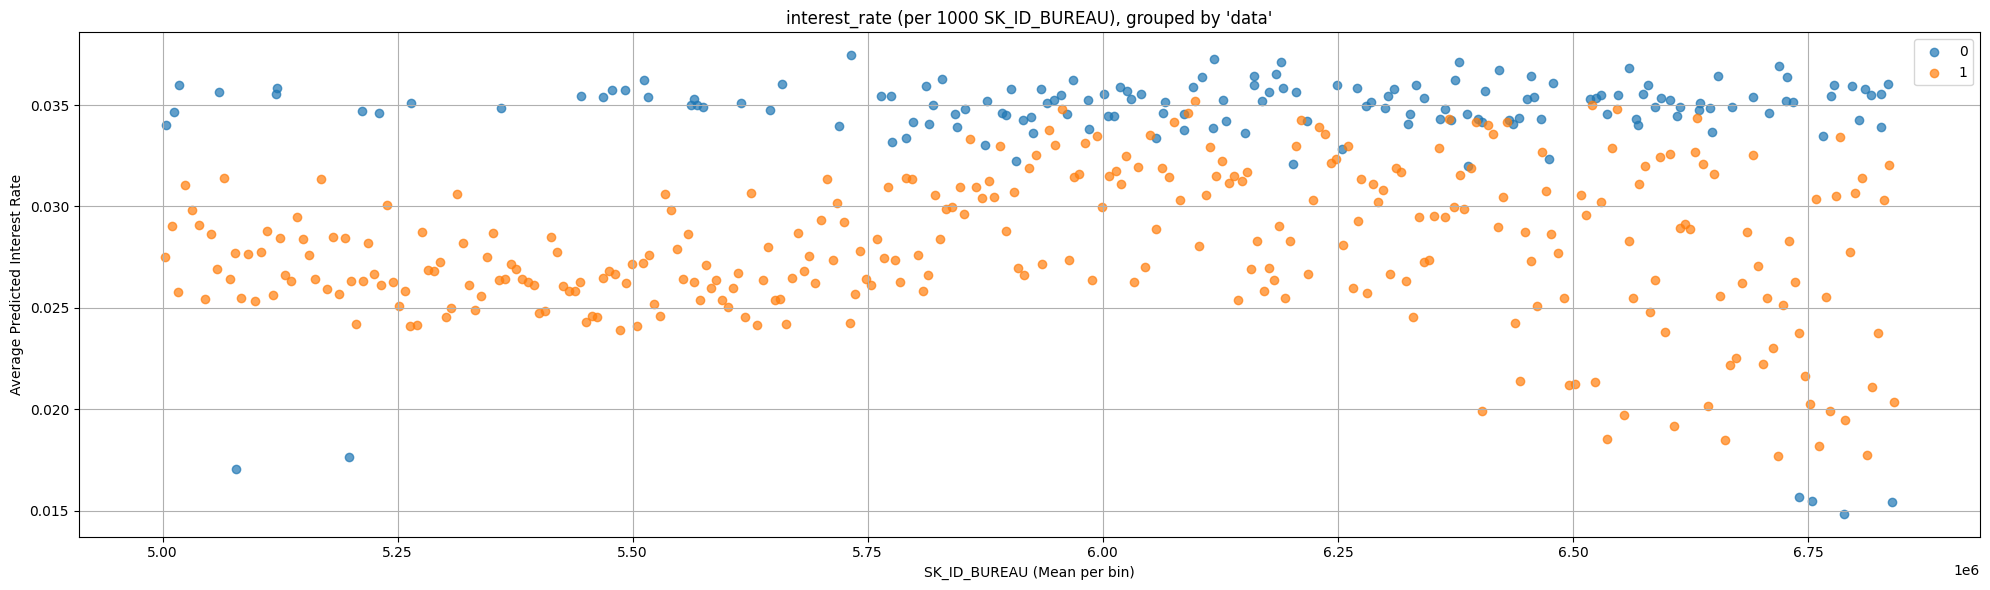

In [150]:
trte_sorted = trte.sort_values("SK_ID_BUREAU").reset_index(drop=True)

trte_sorted["group_id"] = trte_sorted.index // 1000

binned = trte_sorted.groupby(["data", "group_id"]).agg({
    "SK_ID_BUREAU": "mean",
    "pred_interest_rate": "median"
}).reset_index()

plt.figure(figsize=(20, 6))
for key, group in binned.groupby("data"):
    plt.scatter(group["SK_ID_BUREAU"], group["pred_interest_rate"], label=str(key), alpha=0.7)

plt.xlabel("SK_ID_BUREAU (Mean per bin)")
plt.ylabel("Average Predicted Interest Rate")
plt.title("interest_rate (per 1000 SK_ID_BUREAU), grouped by 'data'")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# hợp lý, vì lãi suất của train tăng dần, tiến đến ngang dần lãi suất của test (giống như biểu đồ lãi suất theo thời gian của prev ở trên)
# lãi suất của test giữ nguyên theo thời gian là hợp lý (tránh overfit theo thời gian)

In [171]:
# from sklearn.linear_model import Ridge
# from sklearn.metrics import mean_squared_error

# n_folds = 5
# kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# oof_preds = np.zeros((X.shape[0],))
# meta_X = np.zeros((X.shape[0], 1)) 
# models = []

# for i, (train_idx, val_idx) in enumerate(kf.split(X)):
#     X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#     X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

#     dtrain = lgb.Dataset(X_train, y_train)
#     dval = lgb.Dataset(X_val, y_val, reference=dtrain)

#     model = lgb.train(param, dtrain, valid_sets=[dval],
#                       num_boost_round=2000,
#                       callbacks=[lgb.early_stopping(50)])
    
#     preds = model.predict(X_val, num_iteration=model.best_iteration)
#     oof_preds[val_idx] = preds
#     meta_X[val_idx, 0] = preds
#     models.append(model)

# meta_model = Ridge()
# meta_model.fit(meta_X, y)

# final_train_preds = meta_model.predict(meta_X)

# rmse = np.sqrt(mean_squared_error(y, final_train_preds))
# print(f"Stacked model RMSE: {rmse:.4f}")


In [70]:
dtrain = lgb.Dataset(X, y, categorical_feature=["NAME_CONTRACT_TYPE", "NAME_TYPE_SUITE", "WEEKDAY_APPR_PROCESS_START"])

In [72]:
ret = lgb.cv(param, dtrain, 1000, nfold=5, callbacks=[lgb.early_stopping(50), lgb.log_evaluation(10)], seed=SEED)

d:\Data Science\venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1064
[LightGBM] [Info] Number of data points in the train set: 1336171, number of used features: 8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1064
[LightGBM] [Info] Number of data points in the train set: 1336171, number of used features: 8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005371 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1064
[LightGBM] [Info] Number of data

In [162]:
cache_clear(globals())